In [1]:
_repo_root = !git rev-parse --show-toplevel
%cd {_repo_root[0]}
del _repo_root

/Users/alex.shtoff/git/spectral_neuron_paper


# Univariate fitting

Thin wrapper around `paper.experiments.univariate`.


In [2]:
import matplotlib as mpl
import pandas as pd

from paper.experiments import synthetic
from paper.experiments.univariate import PROFILES, run_profile
from paper.plotting import plot_scaling, plot_target_gallery
from paper.targets import TargetSpec
from paper.tuning import summarize_raw

mpl.rcParams["figure.dpi"] = 140


/Users/alex.shtoff/git/spectral_neuron_paper/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
profile_name = "full"
profile = PROFILES[profile_name]
raw_path = synthetic.default_raw_path("univariate", profile_name)
plot_target_kind = "general"

In [4]:
if raw_path.exists():
    raw = pd.read_csv(raw_path)
else:
    raw = run_profile(profile)
    synthetic.write_csv(raw, raw_path)

expected_models = {"unconstrained", "monotone"}
if not expected_models <= set(raw["model"].unique()):
    raise ValueError(f"{raw_path} does not contain {sorted(expected_models)}; rerun this profile")

summary = summarize_raw(raw, profile.train_sizes)
plot_summary = summary.loc[summary["target_kind"] == plot_target_kind].copy()
plot_summary.head()

,target_kind,complexity,noise_std,model,dim,budget,selected_lr,median_test_rmse,q25_test_rmse,q75_test_rmse,n
0,general,5,0.0,unconstrained,5,1,0.1,0.796240,0.596269,1.022360,96
1,general,5,0.0,unconstrained,5,2,0.1,0.614279,0.444385,0.849788,96
2,general,5,0.0,unconstrained,5,5,0.1,0.543267,0.312861,0.679657,96
3,general,5,0.0,unconstrained,5,10,0.1,0.381743,0.246046,0.599874,96
4,general,5,0.0,unconstrained,5,20,0.1,0.263861,0.177213,0.426769,96


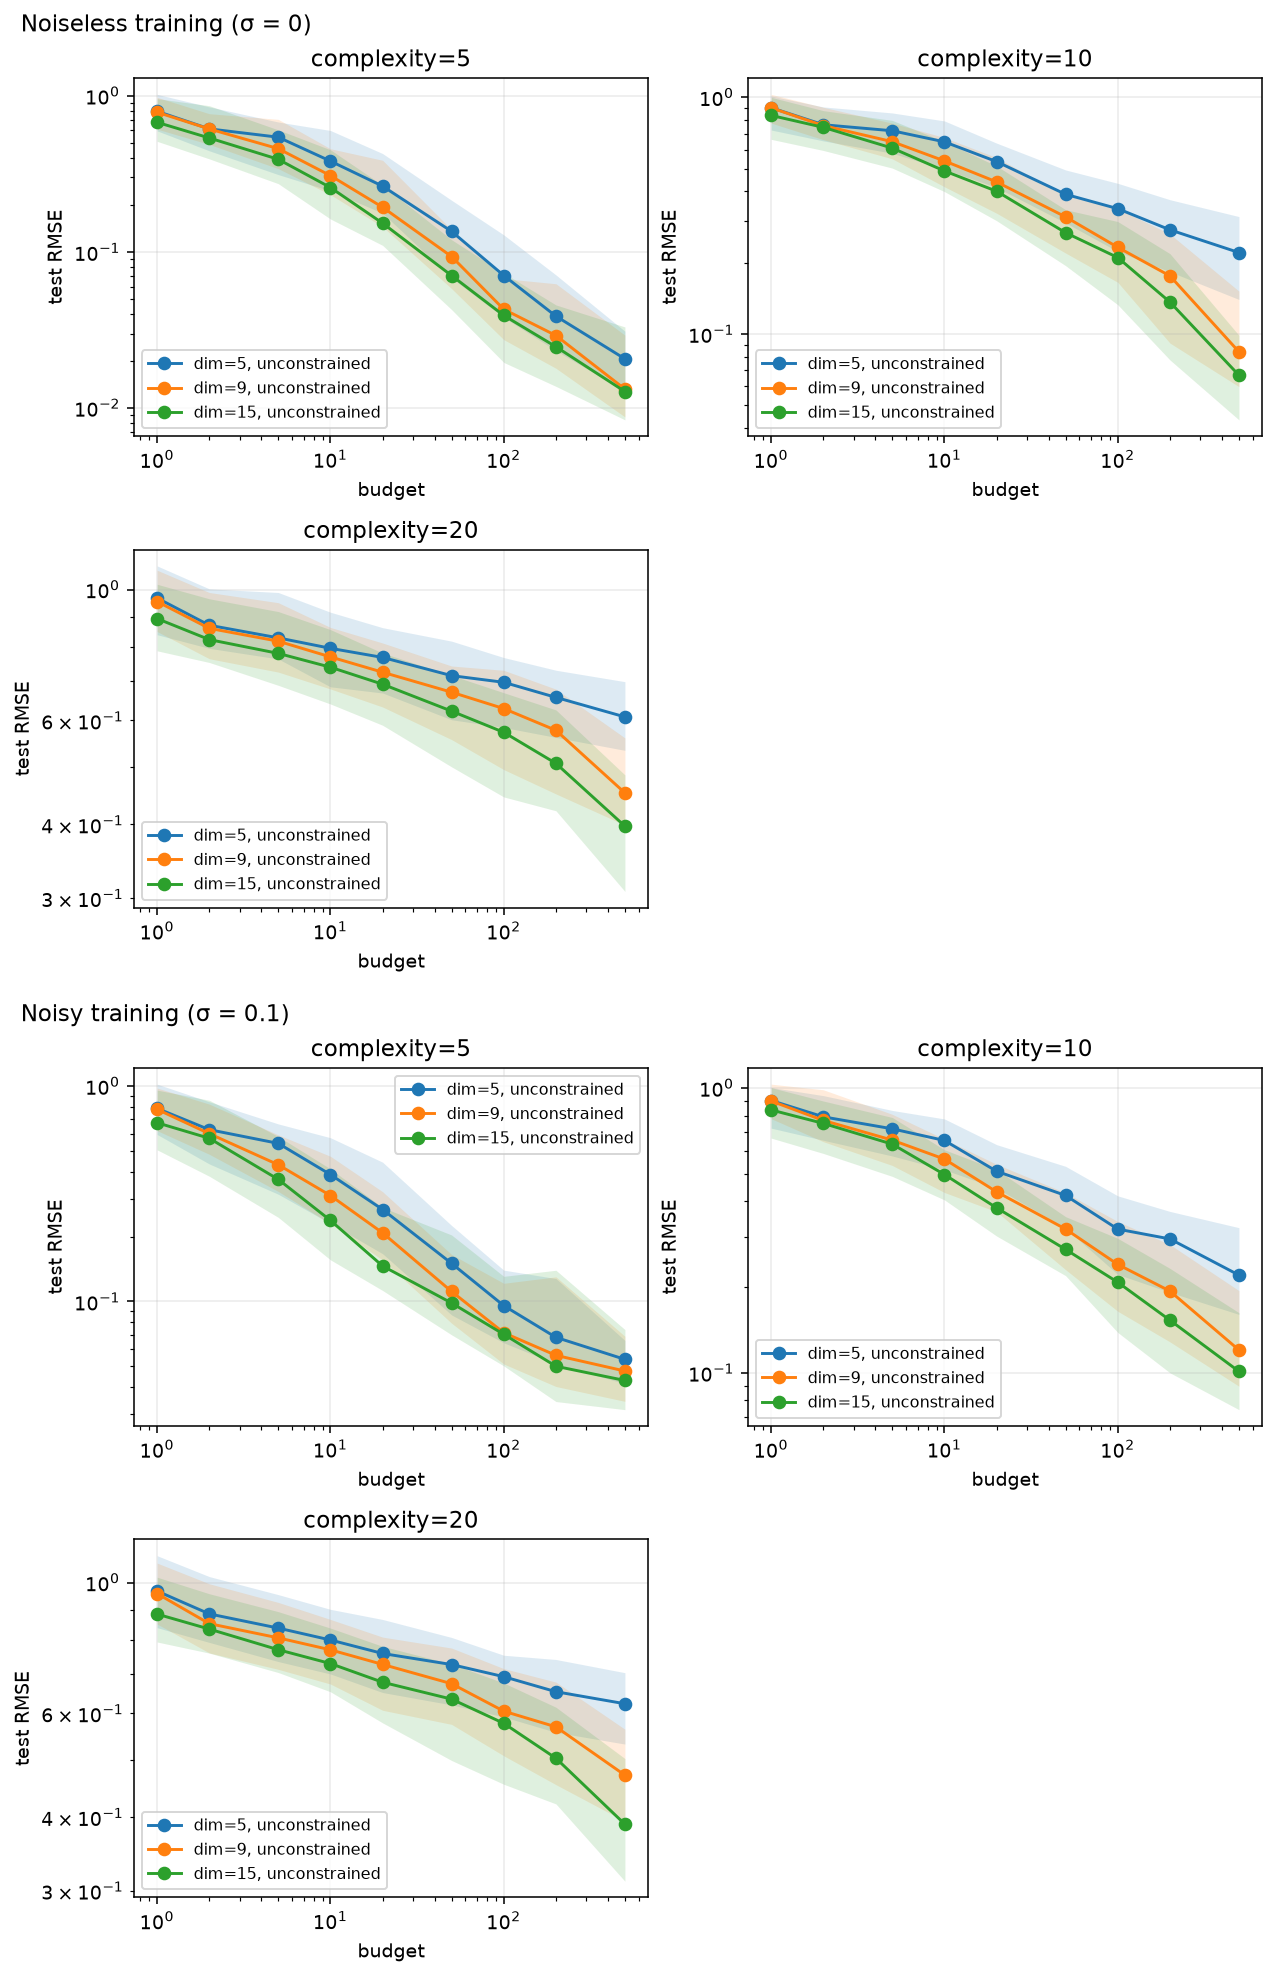

In [5]:
plot_scaling(plot_summary);

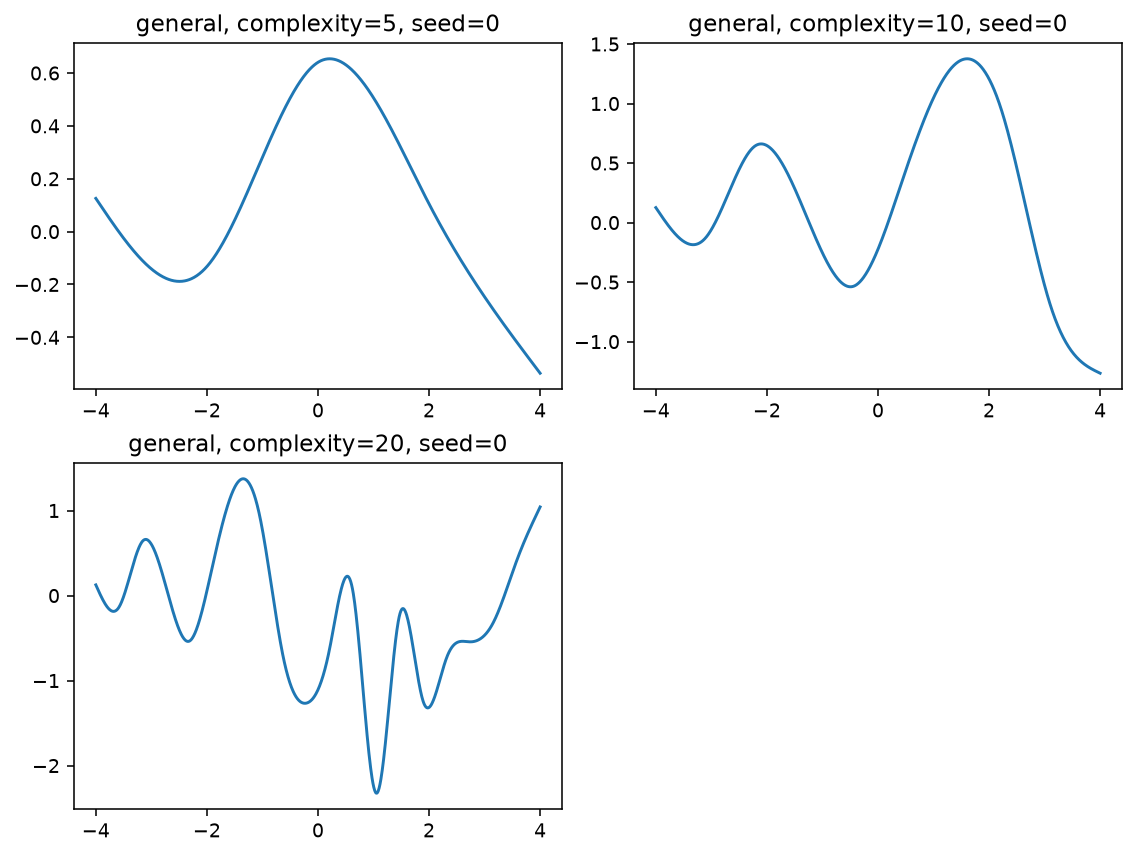

In [6]:
plot_target_gallery([
    TargetSpec(kind=plot_target_kind, complexity=complexity, seed=0)
    for complexity in profile.complexities
]);